# 7-C. KOGAS 환산 — 발전량(MWh) → 가스 송출량(TON)

> PROJECT.md §4 7-C / §5.3 KOGAS 연결(**자격 앵커 = 한국가스공사**). §1.2 검증목표 2의 출력 환산.
> 핵심은 **단위변환**: 전력거래소 자료(시간별 발전량 MW) → KOGAS 자료(일간 가스 송출량 TON).

**작업 순서**
1. 변환계수 보정 — 일별 실측 송출량 vs 집계 발전량으로 ton/MWh 도출·검증(연도·월·기온 안정성).
2. f(평균기온) 검증 — 현장 직관(겨울 효율 변화) 데이터 검증 → 집계 수준 무의미 확인(정직성).
3. 7-A 전국 예측에 변환 적용 → **일별/시간별 예상 송출량(TON)** (최종 산출물).
4. 단가·수입가 상관(간단), 가스가격 메커니즘 개략.
5. 제주(7-B)·전국(7-A) 명제 대비표 마무리.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import lightgbm as lgb

mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
for _f in ['Malgun Gothic','NanumGothic','AppleGothic']:
    try: mpl.rcParams['font.family']=_f; break
    except Exception: pass
mpl.rcParams['axes.unicode_minus']=False
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
SD=Path('../../1. data_fetcher_and_db/second_dataset')

# 전국 시간별 실측(gen_gas_kr) + 기온
lf=pd.read_parquet(SD/'data/land_full.parquet'); lf['timestamp']=pd.to_datetime(lf['timestamp'])
lf['date']=lf['timestamp'].dt.floor('D')
TCOLS=['temp_c_daegwallyeong','temp_c_wonju','temp_c_seosan','temp_c_pohang','temp_c_yeonggwang']
lf['temp_nat']=lf[TCOLS].mean(axis=1)

# 일간 가스 송출량(TON, euc-kr) = KOGAS 실측 출처
so=pd.read_csv(SD/'data/daliy_lng_gen_21-26.csv',encoding='euc-kr')
so.columns=['idx','date','sendout_ton']; so['date']=pd.to_datetime(so['date'])
print('송출량 파일 범위',so.date.min().date(),'~',so.date.max().date(),'| n',len(so))
print('송출량(ton/day) 통계: 평균 %.0f  최소 %d  최대 %d'%(so.sendout_ton.mean(),so.sendout_ton.min(),so.sendout_ton.max()))


송출량 파일 범위 2021-01-01 ~ 2026-03-31 | n 1916
송출량(ton/day) 통계: 평균 68828  최소 34711  최대 113418


## 1. 변환계수 보정 — 일별 실측 송출량 vs 집계 발전량
전력거래소 `gen_gas_kr`(시간별 MW)을 **일 단위로 합산**하면 일 발전량(MWh/day)이다. 이를 KOGAS 일간 송출량(TON)과 맞춰 ton/MWh를 보정한다.
실측 가스발전은 **2022-01부터**(G-10) → 보정 구간 2022-01 이후만 사용.

In [2]:
# 일집계 발전량(MWh) = 시간별 MW 합 (완전한 24시간 일만)
dg=lf.groupby('date').agg(gen_MWh=('gen_gas_kr','sum'), hrs=('gen_gas_kr','count'),
                          temp=('temp_nat','mean')).reset_index()
dg=dg[dg.hrs==24]
cal=pd.merge(dg, so[['date','sendout_ton']], on='date').query('date>="2022-01-01"').copy()
cal['year']=cal.date.dt.year; cal['month']=cal.date.dt.month
cal['ratio']=cal.sendout_ton/cal.gen_MWh
print('보정 구간',cal.date.min().date(),'~',cal.date.max().date(),'| n',len(cal))
r=cal.gen_MWh.corr(cal.sendout_ton)
print('corr(집계 발전량 MWh, 송출량 TON) = %.4f'%r)

x=cal.gen_MWh.values; y=cal.sendout_ton.values
def stt(y,p):
    r2=1-((y-p)**2).sum()/((y-y.mean())**2).sum()
    return r2, np.abs(y-p).mean(), (np.abs(y-p)/y).mean()*100
LHV=15.28  # MWh_th per ton (LNG ~55 GJ/ton)

# ★ 무절편 단일계수 (사용자 확정): ton = K*MWh
K=(x*y).sum()/(x*x).sum()
p=K*x; r2,mae,mape=stt(y,p)
print(f'★ 채택 변환식: ton = {K:.5f} * MWh  (무절편 단일계수)')
print(f'   · {K:.4f} ton/MWh = {1/K:.2f} MWh/ton, 함의 열효율 {1/K/LHV*100:.1f}%')
print(f'   적합: R2={r2:.4f}  MAE={mae:.0f} ton/day  MAPE={mape:.2f}%')
# 참고: 절편식(미채택 — 연도별 절편 불안정)
b1,b0=np.polyfit(x,y,1); r2i,_,mapei=stt(y,b1*x+b0)
print(f'   (참고) 절편식 ton={b1:.4f}*MWh+{b0:.0f}: MAPE={mapei:.2f}% → 연도별 절편 759~9030으로 불안정해 미채택')


보정 구간 2022-01-01 ~ 2026-03-31 | n 1551
corr(집계 발전량 MWh, 송출량 TON) = 0.9717
★ 채택 변환식: ton = 0.15212 * MWh  (무절편 단일계수)
   · 0.1521 ton/MWh = 6.57 MWh/ton, 함의 열효율 43.0%
   적합: R2=0.9366  MAE=2409 ton/day  MAPE=3.63%
   (참고) 절편식 ton=0.1398*MWh+5781: MAPE=3.39% → 연도별 절편 759~9030으로 불안정해 미채택


### 1-1. 변환계수 안정성 — 연도·월
단일계수가 정당하려면 변환비(=송출량/발전량)가 연도·월에 걸쳐 안정해야 한다.
**월별 변환비가 겨울에 치솟지 않으면** 난방용 도시가스 혼입이 아니라 **순수 발전용 송출량**이라는 방증(난방 혼입이면 겨울 비가 부풀어야 함).

연도별 변환비(ton/MWh) + 함의 효율:
       ratio     std    n  eff_pct
year                              
2022  0.1474  0.0043  365  44.4089
2023  0.1535  0.0085  365  42.6230
2024  0.1582  0.0058  366  41.3791
2025  0.1526  0.0074  365  42.8997
2026  0.1564  0.0069   90  41.8443


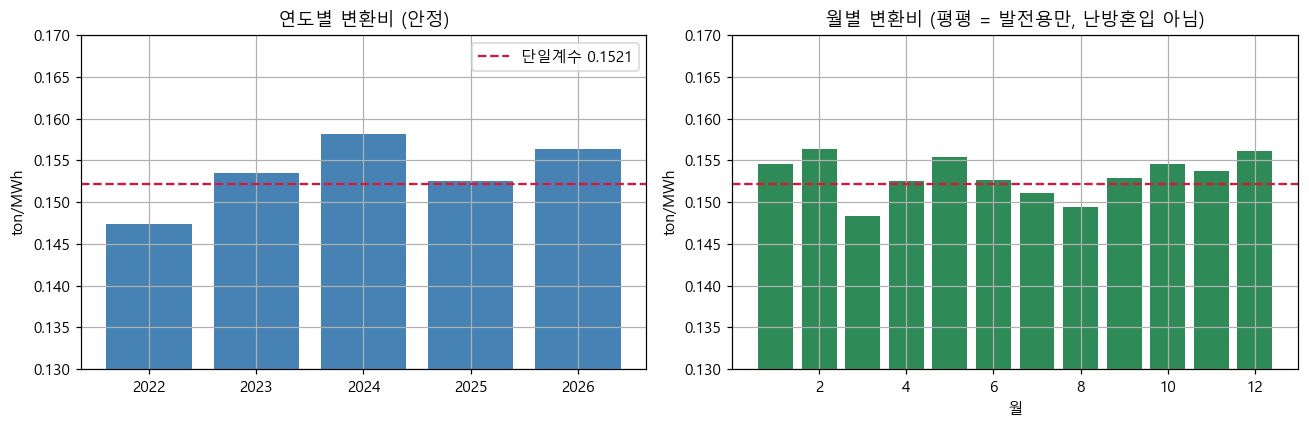

월별 변동폭: 0.1483~0.1564 (±2.6%) → 발전용 LNG 송출량 확인


In [3]:
cal['ratio']=cal.sendout_ton/cal.gen_MWh
yr=cal.groupby('year').agg(ratio=('ratio','mean'), std=('ratio','std'), n=('ratio','size'))
yr['eff_pct']=1/yr['ratio']/LHV*100
print('연도별 변환비(ton/MWh) + 함의 효율:'); print(yr.round(4).to_string())
mo=cal.groupby('month')['ratio'].mean()
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(yr.index.astype(str),yr['ratio'],color='steelblue'); ax[0].axhline(K,color='crimson',ls='--',label=f'단일계수 {K:.4f}')
ax[0].set_title('연도별 변환비 (안정)'); ax[0].set_ylabel('ton/MWh'); ax[0].set_ylim(0.13,0.17); ax[0].legend()
ax[1].bar(mo.index,mo.values,color='seagreen'); ax[1].axhline(K,color='crimson',ls='--')
ax[1].set_title('월별 변환비 (평평 = 발전용만, 난방혼입 아님)'); ax[1].set_xlabel('월'); ax[1].set_ylabel('ton/MWh'); ax[1].set_ylim(0.13,0.17)
plt.tight_layout(); plt.savefig(FIG/'7c_factor_stability.png'); plt.show()
yr.round(4).to_csv(TAB/'7c_factor_by_year.csv')
print('월별 변동폭: %.4f~%.4f (±%.1f%%) → 발전용 LNG 송출량 확인'%(mo.min(),mo.max(),(mo.max()-mo.min())/K/2*100))


## 2. f(평균기온) 검증 (현장 직관 데이터 대조 — 정직성 §5.4)
**현장 가설**: 겨울철 발전기 흡입공기 밀도↑ → 효율 변동 → 변환계수가 기온의 함수일 수 있다.
→ 데이터로 검증한다. 발전기 1대 단위로는 맞지만 **전국 fleet 일집계**에선 신호가 살아남는지 본다.

corr(변환비, 평균기온) = -0.141 (≈0, 거의 무관)

기온구간별 변환비:
            mean  size
tbin                  
(-15, 0]  0.1548   207
(0, 5]    0.1550   252
(5, 10]   0.1510   189
(10, 15]  0.1529   231
(15, 20]  0.1551   224
(20, 25]  0.1522   247
(25, 35]  0.1502   201

f(기온) 모델: ton=(0.15321-0.000096*temp)*MWh  MAPE=3.57% (단일계수 3.63% 대비 +0.05%p)
  유효계수: 0°C 0.1532 → 25°C 0.1508 (변동 1.6%, 부호는 현장 직관과 반대로 약함)


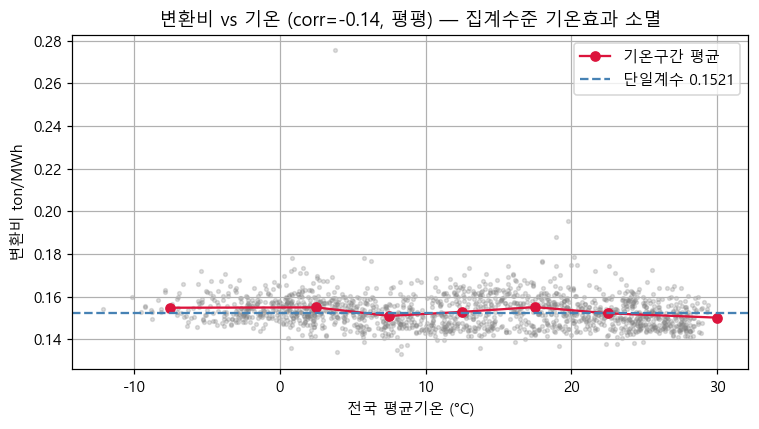


결론: 발전기 1대 단위 기온효과는 실재하나, 전국 fleet 일집계에선 부분부하·급전구성이 압도해 신호 소멸
      (변환비-기온 상관 -0.14, f(기온) 추가해도 +0.05%p) → 단일계수 유지·보고서 문서화.


In [4]:
rt=cal.ratio.corr(cal.temp)
cal['tbin']=pd.cut(cal.temp,[-15,0,5,10,15,20,25,35])
tb=cal.groupby('tbin',observed=True)['ratio'].agg(['mean','size'])
print('corr(변환비, 평균기온) = %.3f (≈0, 거의 무관)'%rt)
print('\n기온구간별 변환비:'); print(tb.round(4).to_string())

# 기온 상호작용 모델: ton = (a + b*temp)*MWh  vs 단일계수
t=cal.temp.values
X=np.column_stack([x, x*t]); coef,*_=np.linalg.lstsq(X,y,rcond=None); pT=X@coef
r2T,_,mapeT=stt(y,pT)
print(f'\nf(기온) 모델: ton=({coef[0]:.5f}{coef[1]:+.6f}*temp)*MWh  MAPE={mapeT:.2f}% (단일계수 {mape:.2f}% 대비 {mape-mapeT:+.2f}%p)')
print(f'  유효계수: 0°C {coef[0]:.4f} → 25°C {coef[0]+coef[1]*25:.4f} (변동 {abs(coef[1]*25)/K*100:.1f}%, 부호는 현장 직관과 반대로 약함)')

fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(cal.temp,cal.ratio,s=6,alpha=0.25,color='gray')
ctr=[iv.mid for iv in tb.index]; ax.plot(ctr,tb['mean'].values,'-o',color='crimson',label='기온구간 평균')
ax.axhline(K,color='steelblue',ls='--',label=f'단일계수 {K:.4f}')
ax.set_xlabel('전국 평균기온 (°C)'); ax.set_ylabel('변환비 ton/MWh')
ax.set_title(f'변환비 vs 기온 (corr={rt:.2f}, 평평) — 집계수준 기온효과 소멸'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'7c_factor_vs_temp.png'); plt.show()
tb.round(4).to_csv(TAB/'7c_factor_by_temp.csv')
print('\n결론: 발전기 1대 단위 기온효과는 실재하나, 전국 fleet 일집계에선 부분부하·급전구성이 압도해 신호 소멸')
print('      (변환비-기온 상관 %.2f, f(기온) 추가해도 %+.2f%%p) → 단일계수 유지·보고서 문서화.'%(rt,mape-mapeT))


## 3. ★ 최종 산출물 — 전국 예측 → 예상 가스 송출량(TON)
**7-A2(이용률 정규화판, `lgbm_land_gas_util.txt`)**으로 test 2026 가스발전(MW) 예측 → ×K → 예상 송출량.
7-A2는 LNG 설비 증설을 이용률 정규화로 흡수해 7-A의 2026 과소예측(bias −5.7%)을 보정한 권장 서빙판.
**일별 주산출** + **시간별 분배**(시간별 발전 형상 × K, 일합 정합). 7-A(절대)도 비교용으로 함께 환산.

In [5]:
META=__import__('json').load(open('model_meta_util.json',encoding='utf-8'))
FEATS=META['features']; TARGET='gen_gas_kr'
# 월별 LNG 용량(ffill) 병합
cap=pd.read_csv(SD/'kr_elec_capa.csv',encoding='euc-kr').rename(columns={'기간':'period','지역':'region','LNG':'LNG_cap'})
cap=cap[cap['region']=='합계'].copy(); cap['ym']=pd.to_datetime(cap['period'],format='%b-%y').dt.to_period('M')
cap['LNG_cap']=pd.to_numeric(cap['LNG_cap'],errors='coerce'); cap=cap[['ym','LNG_cap']].dropna().sort_values('ym')
lf['ym']=lf['timestamp'].dt.to_period('M')
_full=pd.period_range(lf['ym'].min(),lf['ym'].max(),freq='M')
cap=cap.set_index('ym').reindex(_full).ffill().rename_axis('ym').reset_index()
te=lf[lf.year==2026].merge(cap,on='ym',how='left').dropna(subset=FEATS+[TARGET,'LNG_cap']).copy()
te['day_type']=te['day_type'].astype('category')
# 7-A2 이용률 → ×용량 복원
bst_u=lgb.Booster(model_file='lgbm_land_gas_util.txt')
te['pred_gen_MW']=np.clip(bst_u.predict(te[FEATS])*te['LNG_cap'].values, 0, None)
# 7-A 절대(비교용)
bst_a=lgb.Booster(model_file='lgbm_land_gas.txt')
te['pred_gen_MW_7A']=np.clip(bst_a.predict(te[FEATS]), 0, None)
te['pred_sendout_ton_h']=K*te['pred_gen_MW']      # 시간별 분배(7-A2)
te['actual_gen_MW']=te[TARGET]

dd=te.groupby('date').agg(pred_gen_MWh=('pred_gen_MW','sum'), pred_gen_MWh_7A=('pred_gen_MW_7A','sum'),
                          actual_gen_MWh=('actual_gen_MW','sum'), hrs=('pred_gen_MW','size')).reset_index()
dd=dd[dd.hrs==24]
dd['pred_sendout_ton']=K*dd['pred_gen_MWh']                # 7-A2 환산(주산출)
dd['pred_sendout_ton_7A']=K*dd['pred_gen_MWh_7A']          # 7-A 환산(비교)
dd['actual_sendout_ton_fromgen']=K*dd['actual_gen_MWh']
dd=dd.merge(so[['date','sendout_ton']].rename(columns={'sendout_ton':'kogas_actual_ton'}),on='date',how='left')
dd.to_csv(TAB/'7c_daily_sendout_forecast_2026.csv',index=False)
te[['timestamp','date','pred_gen_MW','pred_sendout_ton_h']].to_csv(TAB/'7c_hourly_sendout_forecast_2026.csv',index=False)

# ★ 오차 분해 (정직성)
v=dd.dropna(subset=['kogas_actual_ton']).copy()
def stt2(yt,yp):
    r2=1-((yt-yp)**2).sum()/((yt-yt.mean())**2).sum()
    return r2, np.abs(yt-yp).mean(), (np.abs(yt-yp)/yt).mean()*100, ((yp-yt)/yt).mean()*100
# (a) 변환만: 실측 발전량 → 송출량 (7-C 산출물 자체의 품질)
ra,_,mapa,bia=stt2(v.kogas_actual_ton.values, v.actual_sendout_ton_fromgen.values)
# (b) end-to-end 7-A2(주산출)
rb,maeb,mapb,bib=stt2(v.kogas_actual_ton.values, v.pred_sendout_ton.values)
# (c) end-to-end 7-A(보정 전 비교)
_,_,mapb0,bib0=stt2(v.kogas_actual_ton.values, v.pred_sendout_ton_7A.values)
print(f'★ 오차 분해  (n={len(v)}, test 2026)')
print(f'  (a) 변환만 [실측발전→송출량] vs KOGAS    : MAPE {mapa:.2f}%  bias {bia:+.1f}%  ← 7-C 변환 품질(핵심)')
print(f'  (b) end-to-end [7-A2이용률예측→송출량]   : MAPE {mapb:.2f}%  bias {bib:+.1f}%  ← ★ 권장 산출')
print(f'  (c) end-to-end [7-A 절대예측→송출량]     : MAPE {mapb0:.2f}%  bias {bib0:+.1f}%  ← 보정 전(과소)')
print(f'  → 7-A2(이용률 정규화)가 7-A의 2026 과소예측을 보정: end-to-end bias {bib0:+.1f}% → {bib:+.1f}%, MAPE {mapb0:.1f}% → {mapb:.1f}%.')
mapee=mapb; maee=maeb


★ 오차 분해  (n=68, test 2026)
  (a) 변환만 [실측발전→송출량] vs KOGAS    : MAPE 3.68%  bias -2.9%  ← 7-C 변환 품질(핵심)
  (b) end-to-end [7-A2이용률예측→송출량]   : MAPE 7.29%  bias -3.3%  ← ★ 권장 산출
  (c) end-to-end [7-A 절대예측→송출량]     : MAPE 13.63%  bias -13.0%  ← 보정 전(과소)
  → 7-A2(이용률 정규화)가 7-A의 2026 과소예측을 보정: end-to-end bias -13.0% → -3.3%, MAPE 13.6% → 7.3%.


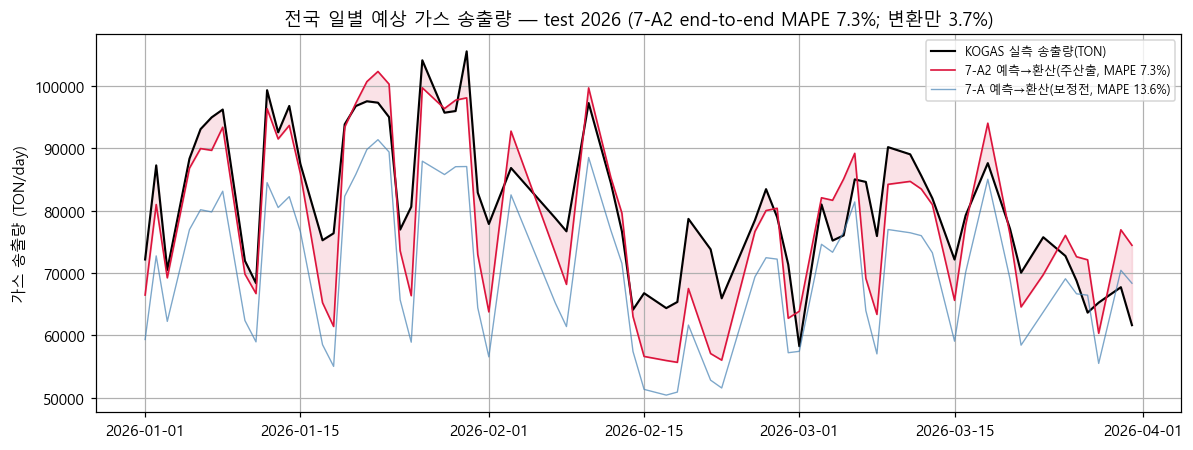

      date  pred_gen_MWh  pred_sendout_ton  pred_sendout_ton_7A  kogas_actual_ton
2026-01-01      436735.0           66438.0              59307.0           72144.0
2026-01-02      532181.0           80958.0              72718.0           87241.0
2026-01-03      454876.0           69198.0              62211.0           70478.0
2026-01-05      570529.0           86792.0              76933.0           88316.0
2026-01-06      591189.0           89934.0              80123.0           93050.0
2026-01-07      589338.0           89653.0              79769.0           94942.0
2026-01-08      613718.0           93362.0              83095.0           96198.0
2026-01-10      458845.0           69802.0              62358.0           71938.0


In [6]:
fig,ax=plt.subplots(figsize=(11,4.2))
ax.plot(v.date,v.kogas_actual_ton,'-',color='black',lw=1.4,label='KOGAS 실측 송출량(TON)')
ax.plot(v.date,v.pred_sendout_ton,'-',color='crimson',lw=1.1,label=f'7-A2 예측→환산(주산출, MAPE {mapb:.1f}%)')
ax.plot(v.date,v.pred_sendout_ton_7A,'-',color='steelblue',lw=0.9,alpha=0.7,label=f'7-A 예측→환산(보정전, MAPE {mapb0:.1f}%)')
ax.fill_between(v.date,v.kogas_actual_ton,v.pred_sendout_ton,alpha=0.12,color='crimson')
ax.set_title(f'전국 일별 예상 가스 송출량 — test 2026 (7-A2 end-to-end MAPE {mapee:.1f}%; 변환만 {mapa:.1f}%)')
ax.set_ylabel('가스 송출량 (TON/day)'); ax.legend(loc='upper right',fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'7c_sendout_forecast.png'); plt.show()
print(dd[['date','pred_gen_MWh','pred_sendout_ton','pred_sendout_ton_7A','kogas_actual_ton']].head(8).round(0).to_string(index=False))


## 4. 단가·수입가 상관 (간단 — 중점 아님)
KOGAS 월별 발전용 단가(`tariff_gen_won_per_GJ`)·수입단가(`import_usd_per_MMBTU`)와 월 송출량·환산 가스비의 상관만 본다.
**송출량(TON) → 가스비(원)** = 송출량 × 열량(GJ/ton) × 발전용단가(원/GJ). 비용 규모 감각용.

월 상관: corr(송출량, 발전용단가)=-0.07  corr(송출량, 수입단가)=-0.03
→ 송출량(물량)과 단가(가격)는 독립적으로 움직임(물량=계통 급전, 가격=원료시장). 가스비는 둘의 곱.


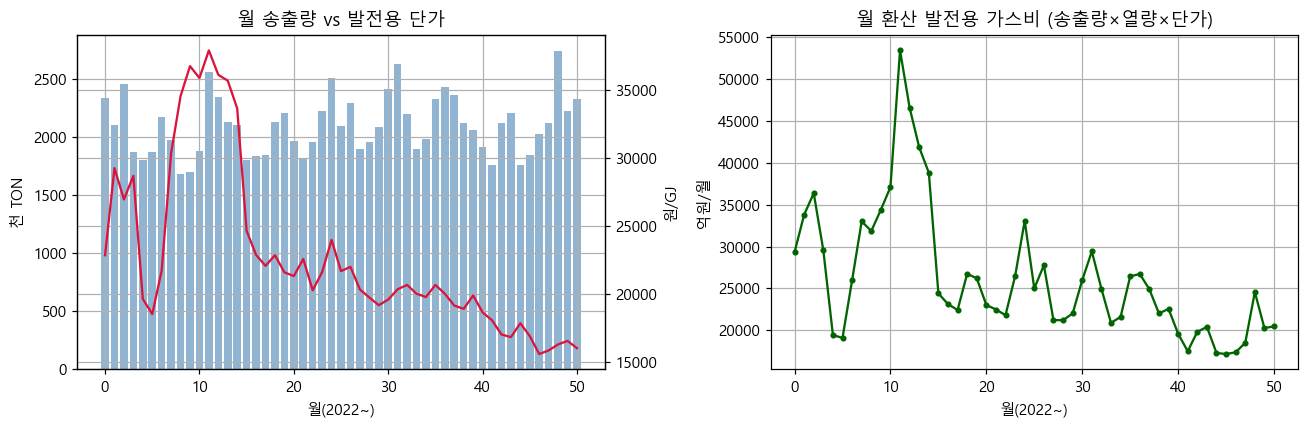

월 발전용 가스비 범위: 17186~53375 억원


In [7]:
km=pd.read_parquet(SD/'data/kogas_monthly.parquet')
km['ym']=km['ym'].astype(str)
mon=cal.copy(); mon['ym']=mon.date.dt.to_period('M').astype(str)
ms=mon.groupby('ym').agg(sendout_ton=('sendout_ton','sum'), gen_MWh=('gen_MWh','sum')).reset_index()
ms=ms.merge(km,on='ym',how='left')
GJ_PER_TON=55.0  # LNG 발열량 근사
ms['gas_cost_won']=ms['sendout_ton']*GJ_PER_TON*ms['tariff_gen_won_per_GJ']
ms['gas_cost_eok']=ms['gas_cost_won']/1e8  # 억원
c1=ms[['sendout_ton','tariff_gen_won_per_GJ']].corr().iloc[0,1]
c2=ms[['sendout_ton','import_usd_per_MMBTU_avg']].corr().dropna().iloc[0,1] if ms['import_usd_per_MMBTU_avg'].notna().sum()>2 else np.nan
print('월 상관: corr(송출량, 발전용단가)=%.2f  corr(송출량, 수입단가)=%.2f'%(c1,c2))
print('→ 송출량(물량)과 단가(가격)는 독립적으로 움직임(물량=계통 급전, 가격=원료시장). 가스비는 둘의 곱.')

fig,ax=plt.subplots(1,2,figsize=(12,4))
axb=ax[0].twinx()
ax[0].bar(range(len(ms)),ms['sendout_ton']/1e3,color='steelblue',alpha=0.6,label='송출량(천TON)')
axb.plot(range(len(ms)),ms['tariff_gen_won_per_GJ'],color='crimson',lw=1.5,label='발전용단가(원/GJ)')
ax[0].set_title('월 송출량 vs 발전용 단가'); ax[0].set_xlabel('월(2022~)'); ax[0].set_ylabel('천 TON'); axb.set_ylabel('원/GJ')
ax[1].plot(range(len(ms)),ms['gas_cost_eok'],'-o',ms=3,color='darkgreen')
ax[1].set_title('월 환산 발전용 가스비 (송출량×열량×단가)'); ax[1].set_xlabel('월(2022~)'); ax[1].set_ylabel('억원/월')
plt.tight_layout(); plt.savefig(FIG/'7c_price_correlation.png'); plt.show()
ms.round(2).to_csv(TAB/'7c_monthly_price_cost.csv',index=False)
print('월 발전용 가스비 범위: %.0f~%.0f 억원'%(ms['gas_cost_eok'].min(),ms['gas_cost_eok'].max()))


## 5. 가스가격 메커니즘 개략 (유가/천연가스 → 발전용 단가)
> 중점이 아니므로 메커니즘만 정리. KOGAS 발전용 도매단가는 대략 **원료비 + 공급비**로 연동된다.

- **원료비(연동)**: LNG 수입단가는 장기계약이 유가(JCC, 후행 평균)에 연동 + 현물(JKM/천연가스 spot)이 섞인다. 따라서 **유가 상승 → 시차(보통 3~5개월) 후 수입단가↑ → 발전용 단가↑**.
- **환율**: 수입단가는 USD/MMBTU → 원/GJ 환산에 **원·달러 환율**이 직접 곱해진다(환율↑ → 원화단가↑).
- **공급비·정산**: KOGAS 공급비(고정)+미수금 정산이 더해져 분기·월 고시단가로 반영(즉시 아닌 시차).
- **요약 흐름**: `유가(JCC)·천연가스 현물(JKM) + 환율 → (시차) 수입단가(USD/MMBTU) → ×환율 → 원료비 → +공급비 → 발전용 단가(원/GJ)`.
- **본 프로젝트 적용**: 송출량(TON, 물량)은 7단계가 net_load로 예측, 가격(원/GJ)은 위 외생 시장변수 → **가스비 = 예측 송출량 × 열량 × 고시단가**로 분리 산출(물량과 가격은 독립이라 곱으로 합성). 가격 예측 자체는 비목표(§1.3).


## 6. 명제 대비표 마무리 — 제주(7-B) vs 전국(7-A) + KOGAS 환산(7-C)

In [8]:
summary=pd.DataFrame([
 ['검증목표','목표1 입증(제주)','목표2 확증(전국)'],
 ['타깃','only_gen 실측 LNG(2020-24)','gen_gas_kr 실측(2022+)'],
 ['net_load↔가스 상관','0.777(안정창)','0.83'],
 ['예측 R²(test)','0.50 (작은계통 한계)','0.78'],
 ['신재생 대체효과(PDP)','−0.314 MW/MW (강함)','−0.017 MW/MW (미미)'],
 ['침투율','높음(~17.5%)','낮음(~2.5%, 자가소비 숨음)'],
 ['역할','대체효과 직접 입증','수요주도 확증 + 절대규모'],
],columns=['항목','제주 7-B','전국 7-A']).set_index('항목')
print(summary.to_string())
summary.to_csv(TAB/'7c_thesis_comparison.csv')
print()
print('7-C KOGAS 환산 결론:')
print(f'  · 변환식 = {K:.4f}*MWh (무절편 단일계수, 열효율 ~{1/K/LHV*100:.0f}%, 월·연 안정 → 발전용 송출량 확인)')
print(f'  · 변환계수 품질(핵심): 실측발전→송출량 MAPE {mapa:.1f}% | 7-A2 end-to-end {mapb:.1f}% bias {bib:+.0f}% (7-A 보정전 {mapb0:.1f}%/{bib0:+.0f}%)')
print(f'  · 최종 산출: test 2026 일별/시간별 예상 송출량(TON) — tab/7c_*_sendout_forecast_2026.csv')
print(f'  · 단가·수입가는 물량과 독립(상관 낮음) → 가스비 = 송출량 × 열량 × 고시단가로 합성')
print('  · 자격앵커 KOGAS(§5.3·§2) 충족: 발전량 예측을 KOGAS 송출량(TON)·단가로 실제 환산')


                                  제주 7-B                전국 7-A
항목                                                            
검증목표                          목표1 입증(제주)            목표2 확증(전국)
타깃              only_gen 실측 LNG(2020-24)  gen_gas_kr 실측(2022+)
net_load↔가스 상관                0.777(안정창)                  0.83
예측 R²(test)               0.50 (작은계통 한계)                  0.78
신재생 대체효과(PDP)          −0.314 MW/MW (강함)     −0.017 MW/MW (미미)
침투율                           높음(~17.5%)    낮음(~2.5%, 자가소비 숨음)
역할                            대체효과 직접 입증        수요주도 확증 + 절대규모

7-C KOGAS 환산 결론:
  · 변환식 = 0.1521*MWh (무절편 단일계수, 열효율 ~43%, 월·연 안정 → 발전용 송출량 확인)
  · 변환계수 품질(핵심): 실측발전→송출량 MAPE 3.7% | 7-A2 end-to-end 7.3% bias -3% (7-A 보정전 13.6%/-13%)
  · 최종 산출: test 2026 일별/시간별 예상 송출량(TON) — tab/7c_*_sendout_forecast_2026.csv
  · 단가·수입가는 물량과 독립(상관 낮음) → 가스비 = 송출량 × 열량 × 고시단가로 합성
  · 자격앵커 KOGAS(§5.3·§2) 충족: 발전량 예측을 KOGAS 송출량(TON)·단가로 실제 환산
